The Nobel Prize has been among the most prestigious international awards since 1901. Each year, awards are bestowed in chemistry, literature, physics, physiology or medicine, economics, and peace. In addition to the honor, prestige, and substantial prize money, the recipient also gets a gold medal with an image of Alfred Nobel (1833 - 1896), who established the prize.

![](Nobel_Prize.png)

The Nobel Foundation has made a dataset available of all prize winners from the outset of the awards from 1901 to 2023. The dataset used in this project is from the Nobel Prize API and is available in the `nobel.csv` file in the `data` folder.

In this project, you'll get a chance to explore and answer several questions related to this prizewinning data. And we encourage you then to explore further questions that you're interested in!

In [8]:
# Loading in required libraries
import pandas as pd
import seaborn as sns
import numpy as np

nobel = pd.read_csv('data/nobel.csv')
nobel.head()

,year,category,prize,motivation,prize_share,laureate_id,laureate_type,full_name,birth_date,birth_city,birth_country,sex,organization_name,organization_city,organization_country,death_date,death_city,death_country
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,160,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Male,Berlin University,Berlin,Germany,1911-03-01,Berlin,Germany
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,569,Individual,Sully Prudhomme,1839-03-16,Paris,France,Male,NaN,NaN,NaN,1907-09-07,Châtenay,France
2,1901,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its...",1/1,293,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Male,Marburg University,Marburg,Germany,1917-03-31,Marburg,Germany
3,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,462,Individual,Jean Henry Dunant,1828-05-08,Geneva,Switzerland,Male,NaN,NaN,NaN,1910-10-30,Heiden,Switzerland
4,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,463,Individual,Frédéric Passy,1822-05-20,Paris,France,Male,NaN,NaN,NaN,1912-06-12,Paris,France


In [9]:
# What is the most commonly awarded gender and birth country?
top_gender = nobel['sex'].value_counts().index[0]
print('Top Gender:', top_gender)

top_country = nobel['birth_country'].mode()[0]
print('\nTop Country:', top_country)

Top Gender: Male

Top Country: United States of America


Max Decade USA: 2000


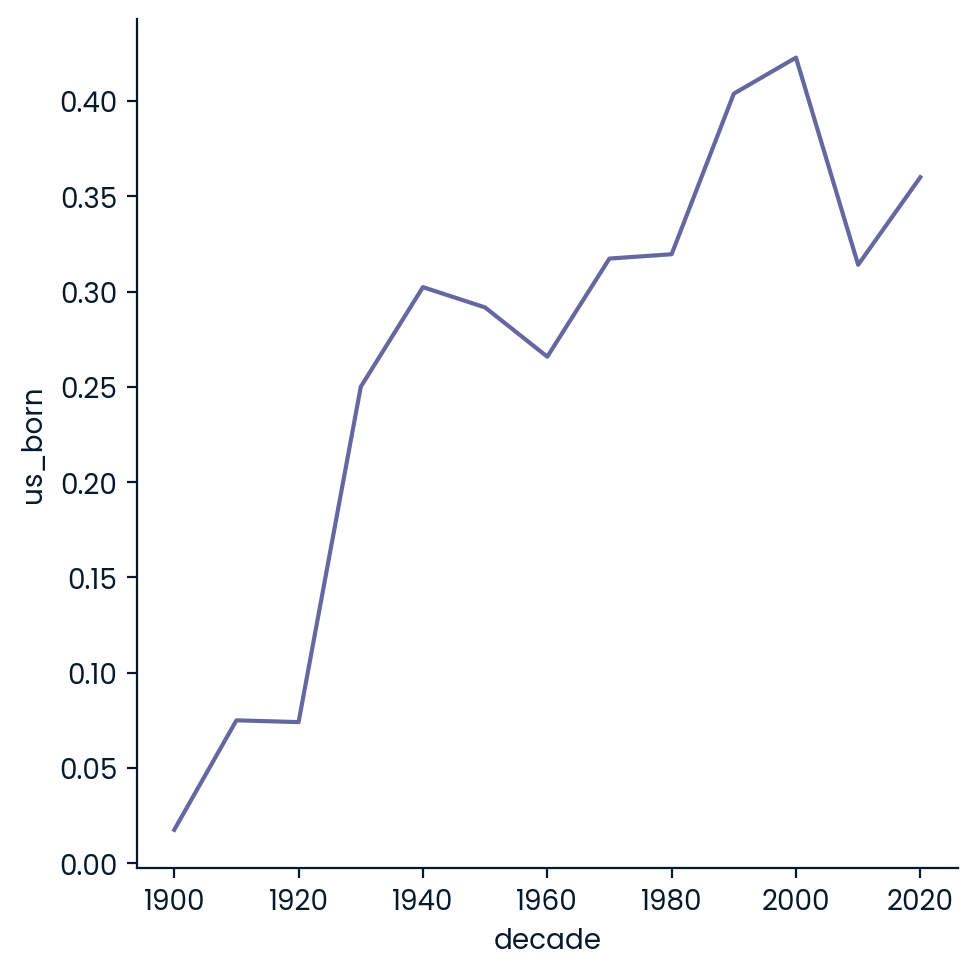

In [10]:
# Decade with the highest ratio of us_born winners.
nobel['us_born'] = nobel['birth_country'] == 'United States of America'

nobel['decade'] = (np.floor(nobel['year'] / 10) * 10).astype(int) 

prop_usa_winners = nobel.groupby('decade', as_index=False)['us_born'].mean()

max_decade_usa = prop_usa_winners[prop_usa_winners['us_born'] == prop_usa_winners['us_born'].max()]['decade'].values[0]

print('Max Decade USA:', max_decade_usa)

sns.relplot(x='decade', y='us_born', kind='line', data=prop_usa_winners);

Max Female Dict: {2020: 'Literature'}


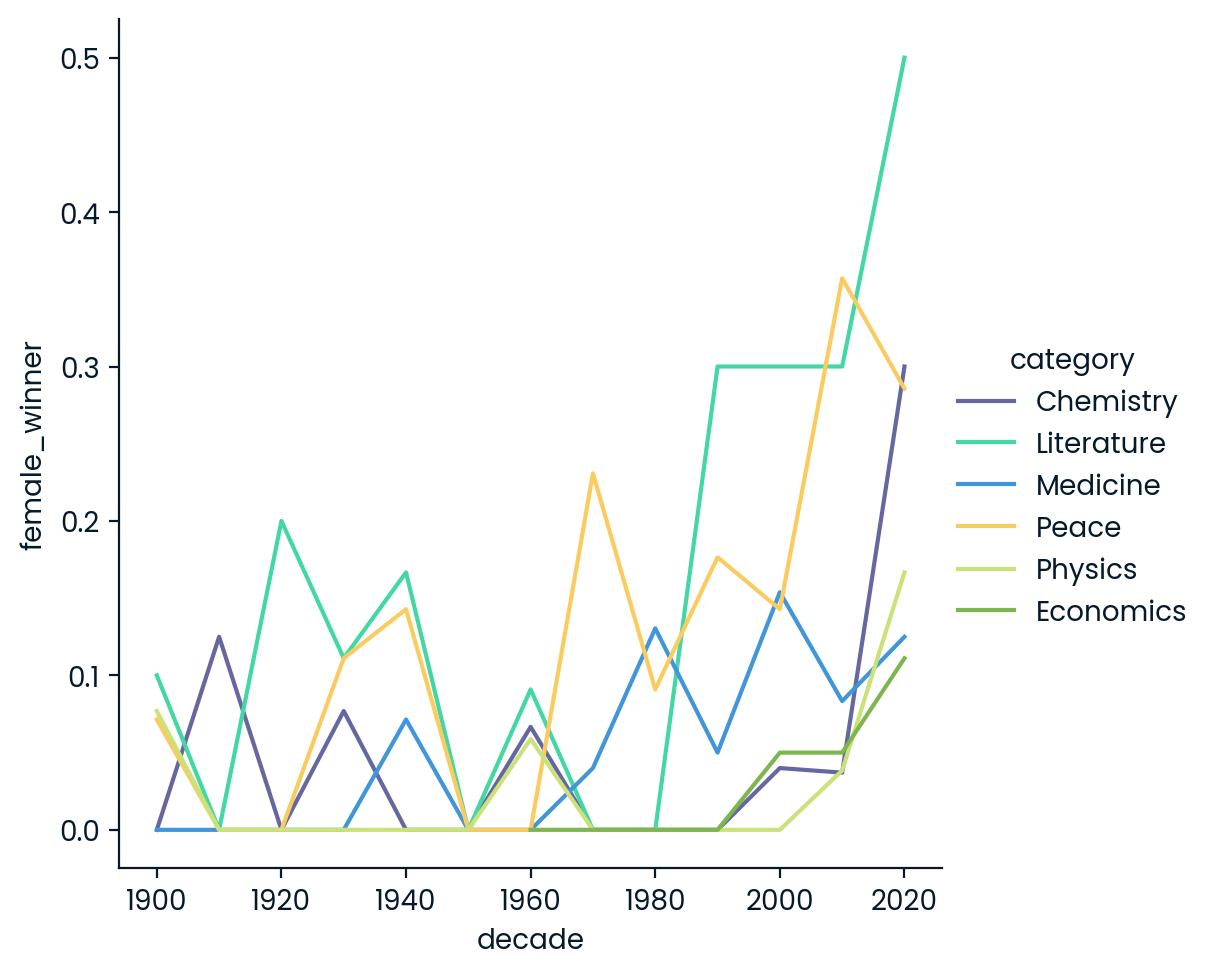

In [11]:
# Decade and category with the highest proportion of female laureates.
nobel['female_winner'] = nobel['sex'] == 'Female'

prop_female_winners = nobel.groupby(['decade', 'category'], as_index=False)['female_winner'].mean()

max_female_decade_category = prop_female_winners[prop_female_winners['female_winner'] == prop_female_winners['female_winner'].max()][['category', 'decade']]

max_female_dict = {max_female_decade_category['decade'].values[0]: max_female_decade_category['category'].values[0]}

print('Max Female Dict:', max_female_dict)

sns.relplot(x='decade', y='female_winner', hue='category', kind='line', data=prop_female_winners);

In [12]:
# First wonan to receive a nobel prize and in what category?
nobel_women = nobel[nobel['female_winner']]

min_row = nobel_women[nobel_women['year'] == nobel_women['year'].min()]

first_woman_name = min_row['full_name'].values[0]
print('First Woman Name:', first_woman_name)
print(f"\nFirst_woman_category: {min_row['category'].values[0]}")

First Woman Name: Marie Curie, née Sklodowska

First_woman_category: Physics


In [13]:
# Which individuals or organizations have won more than one Nobel Prize throughout the years?
name_counts = nobel['full_name'].value_counts()
repeats = name_counts[name_counts >= 2].index
repeat_list = list(repeats)
print('List of Repeated winners:', repeat_list)

List of Repeated winners: ['Comité international de la Croix Rouge (International Committee of the Red Cross)', 'Linus Carl Pauling', 'John Bardeen', 'Frederick Sanger', 'Marie Curie, née Sklodowska', 'Office of the United Nations High Commissioner for Refugees (UNHCR)']
